In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('demo.csv')
display(df.head())


,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,01-01-2025,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,02-01-2025,60.0,Rainy,W,Car,Night,0.0,Serious
2,03-01-2025,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,04-01-2025,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,05-01-2025,70.0,Rainy,W,Bike,Night,0.0,Serious


In [3]:
print(df.head())
print(df.info())
print(df.describe())

         Date  Speed Weather Road_Condition Vehicle_Type   Time  \
0  01-01-2025   45.0   Sunny            Dry         Bike    Day   
1  02-01-2025   60.0   Rainy              W          Car  Night   
2  03-01-2025   80.0   Foggy            Wet        Truck  Night   
3  04-01-2025   50.0   Sunny            Dry          Car    Day   
4  05-01-2025   70.0   Rainy              W         Bike  Night   

   Seatbelt/Helmet Severity  
0              1.0    Minor  
1              0.0  Serious  
2              NaN    Fatal  
3              1.0    Minor  
4              0.0  Serious  
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             48 non-null     str    
 1   Speed            44 non-null     float64
 2   Weather          47 non-null     str    
 3   Road_Condition   48 non-null     str    
 4   Vehicle_Type     45 non-null     str    
 5  

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )

#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")

df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [6]:
df.head()

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,01/01/2025,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,02/01/2025,60.0,Rainy,W,Car,Night,0.0,Serious
2,03/01/2025,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,04/01/2025,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,05/01/2025,70.0,Rainy,W,Bike,Night,0.0,Serious


In [7]:
df['Road_Condition'] = df['Road_Condition'].replace({
'W': 'Wet',
'D': 'Dry'
})

In [8]:
print(df.isnull().sum())

Date                0
Speed               6
Weather             3
Road_Condition      2
Vehicle_Type        5
Time                6
Seatbelt/Helmet    12
Severity            0
dtype: int64


In [9]:
df['Speed'].fillna(df['Speed'].mean(), inplace=True)

C:\Temp\ipykernel_2316\2172377610.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Speed'].fillna(df['Speed'].mean(), inplace=True)


0     45.000000
1     60.000000
2     80.000000
3     50.000000
4     70.000000
5     90.000000
6     69.613636
7     65.000000
8     85.000000
9     40.000000
10    75.000000
11    95.000000
12    35.000000
13    68.000000
14    69.613636
15    48.000000
16    72.000000
17    92.000000
18    52.000000
19    78.000000
20    98.000000
21    69.613636
22    67.000000
23    87.000000
24    49.000000
25    73.000000
26    93.000000
27    41.000000
28    69.000000
29    89.000000
30    69.613636
31    71.000000
32    91.000000
33    54.000000
34    76.000000
35    69.613636
36    44.000000
37    66.000000
38    86.000000
39    47.000000
40    74.000000
41    94.000000
42    69.613636
43    77.000000
44    97.000000
45    42.000000
46    64.000000
47    84.000000
48    51.000000
49    79.000000
Name: Speed, dtype: float64

In [10]:
for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time']:
df[col].fillna(df[col].mode()[0], inplace=True)

IndentationError: expected an indented block after 'for' statement on line 1 (4216851341.py, line 2)

In [11]:
df['Seatbelt/Helmet'].fillna(0, inplace=True)

C:\Temp\ipykernel_2316\2001474051.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Seatbelt/Helmet'].fillna(0, inplace=True)


0     1.0
1     0.0
2     0.0
3     1.0
4     0.0
5     0.0
6     1.0
7     0.0
8     0.0
9     1.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    1.0
16    0.0
17    0.0
18    1.0
19    0.0
20    0.0
21    1.0
22    0.0
23    0.0
24    1.0
25    0.0
26    0.0
27    1.0
28    0.0
29    0.0
30    1.0
31    0.0
32    0.0
33    1.0
34    0.0
35    0.0
36    0.0
37    0.0
38    0.0
39    1.0
40    0.0
41    0.0
42    1.0
43    0.0
44    0.0
45    1.0
46    0.0
47    0.0
48    0.0
49    0.0
Name: Seatbelt/Helmet, dtype: float64

In [12]:
df.dropna(subset=['Severity'], inplace=True)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.isna().sum()

Date                0
Speed               6
Weather             3
Road_Condition      2
Vehicle_Type        5
Time                6
Seatbelt/Helmet    12
Severity            0
dtype: int64

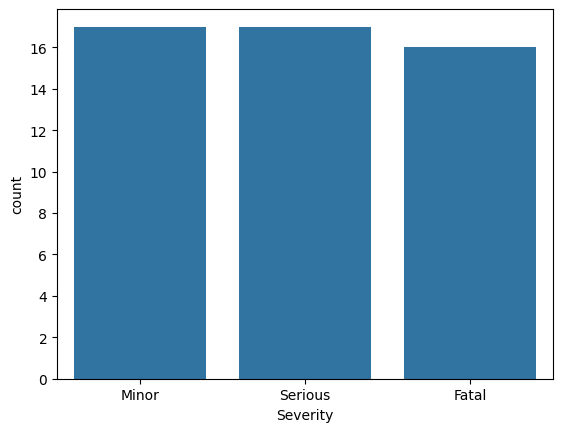

In [15]:
sns.countplot(x='Severity', data=df)
plt.show()

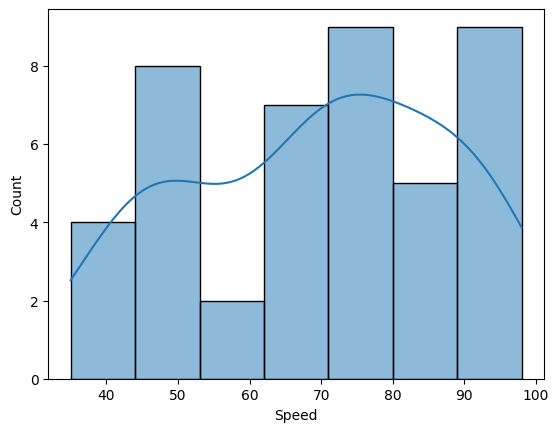

In [16]:
sns.histplot(df['Speed'], kde=True)
plt.show()

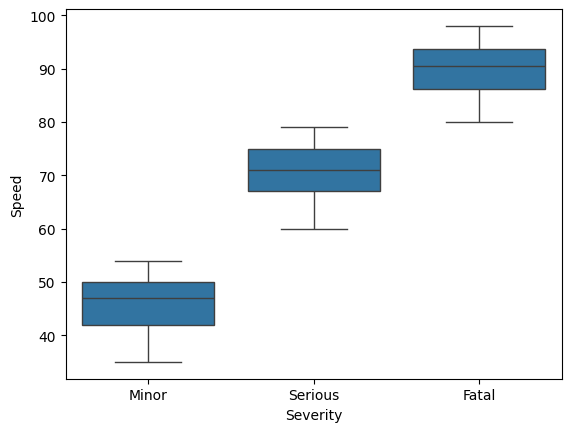

In [17]:
sns.boxplot(x='Severity', y='Speed', data=df)
plt.show()

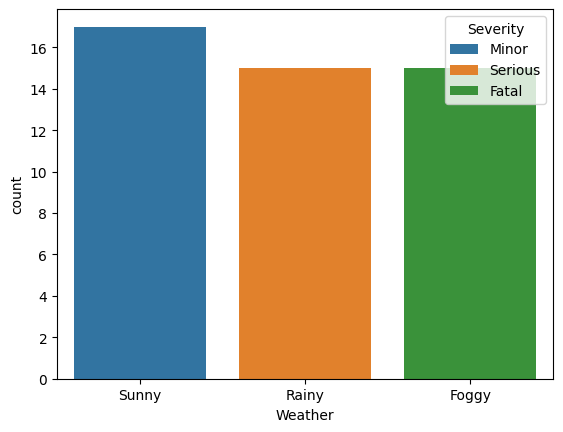

In [18]:
sns.countplot(x='Weather', hue='Severity', data=df)
plt.show()

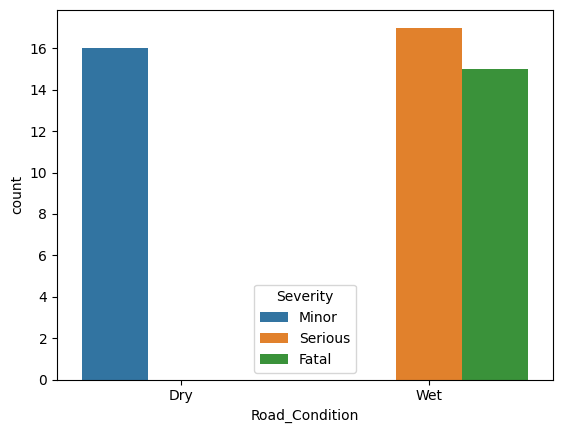

In [19]:
sns.countplot(x='Road_Condition', hue='Severity', data=df)
plt.show()

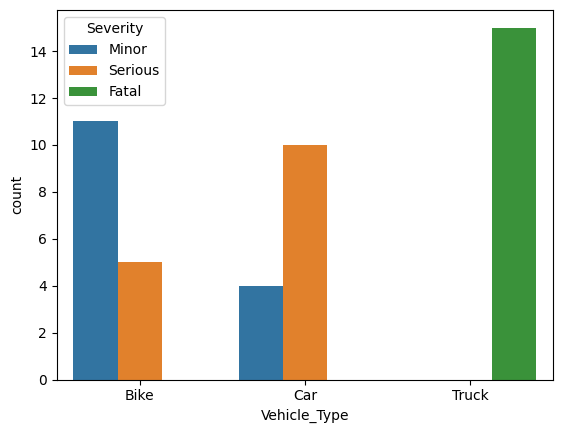

In [20]:
sns.countplot(x='Vehicle_Type', hue='Severity', data=df)
plt.show()

In [21]:
#adding additional Featues and Rows for better accuracy
new_rows = 100
# Create base data
new_data = pd.DataFrame({
'Date': pd.date_range(start='2025-03-01', periods=new_rows, freq='D'),
'Speed': np.random.randint(30, 100, new_rows),
'Weather': np.random.choice(['Sunny', 'Rainy', 'Foggy'], new_rows),
'Road_Condition': np.random.choice(['Dry', 'Wet'], new_rows),
'Vehicle_Type': np.random.choice(['Bike', 'Car', 'Truck'], new_rows),
'Time': np.random.choice(['Day', 'Night'], new_rows),
'Seatbelt/Helmet': np.random.choice([0,1], new_rows),
'Severity': np.random.choice(['Minor', 'Serious', 'Fatal'], new_rows),
'Is_Night': np.random.choice([0,1], new_rows),
'Speed_Category': np.random.choice(['Low', 'Medium', 'High'], new_rows),
'Safety': np.random.choice(['Safe', 'Unsafe'], new_rows)
})

In [22]:
new_data['Is_Night'] = new_data['Time'].apply(lambda x: 1 if x == 'Night' else 0)
df['Is_Night'] = df['Time'].apply(lambda x: 1 if x == 'Night' else 0)

In [26]:
def speed_category(speed):
    if speed < 50:
        return "Low"
    elif speed < 80:
        return "Medium"
    else:
        return "High"
new_data['Speed_Category'] = new_data['Speed'].apply(speed_category)
df['Speed_Category'] = df['Speed'].apply(speed_category)

In [27]:
new_data['Safety'] = new_data['Seatbelt/Helmet'].apply(
lambda x: "Safe" if x == 1 else "Unsafe"
)
df['Safety'] = df['Seatbelt/Helmet'].apply(
lambda x: "Safe" if x == 1 else "Unsafe"
)

In [30]:
def assign_severity(row):
    if row['Speed'] > 85 and row['Road_Condition'] == 'Wet':
        return 'Fatal'
    elif row['Speed'] > 65:
        return 'Serious'
    else:
        return 'Minor'
new_data['Severity'] = new_data.apply(assign_severity, axis=1)
df['Severity'] = df.apply(assign_severity, axis=1)

In [31]:
df = pd.concat([df, new_data], ignore_index=True)

In [32]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )

#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")

df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [33]:
df.isna().sum()

Date                0
Speed               6
Weather             3
Road_Condition      2
Vehicle_Type        5
Time                6
Seatbelt/Helmet    12
Severity            0
Is_Night            0
Safety              0
Speed_Category      0
dtype: int64

In [34]:
df.to_csv("improved_accident_data.csv", index=False)

In [35]:
df = df.drop('Date', axis=1)

In [38]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time', 'Severity', 'Speed_Category', 'Safety']:
    df[col] = df[col].astype(str) # Ensure all values are strings before encoding
    df[col] = encoder.fit_transform(df[col])

display(df.head())

,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Safety,Speed_Category
0,45.0,2,0,0,0,1.0,1,0,0,1
1,60.0,1,1,1,1,0.0,1,1,1,2
2,80.0,0,1,2,1,NaN,2,1,1,0
3,50.0,2,0,1,0,1.0,1,0,0,2
4,70.0,1,1,0,1,0.0,2,1,1,2


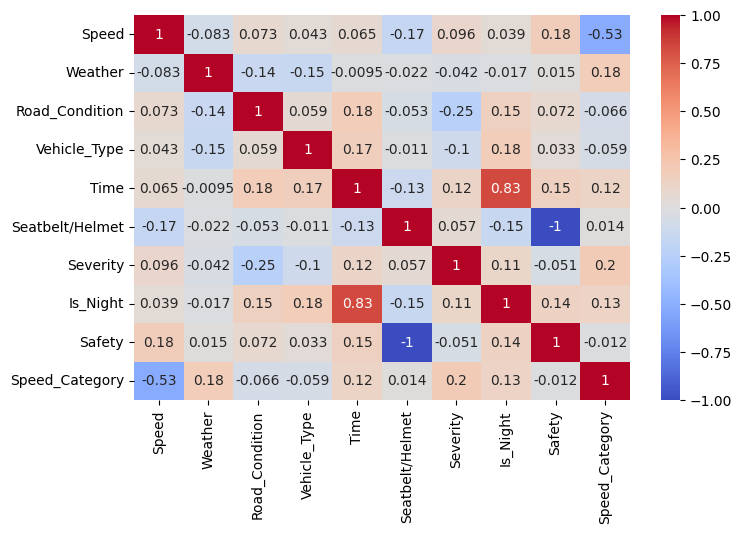

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Speed', 'Seatbelt/Helmet']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [41]:
df.head()

,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Safety,Speed_Category
0,-0.996727,2,0,0,0,1.042938,1,0,0,1
1,-0.291250,1,1,1,1,-0.958830,1,1,1,2
2,0.649386,0,1,2,1,NaN,2,1,1,0
3,-0.761568,2,0,1,0,1.042938,1,0,0,2
4,0.179068,1,1,0,1,-0.958830,2,1,1,2
